### Pacotes importados

In [3]:
import Pkg
Pkg.add("Plots")

using Plots
using LinearAlgebra

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`


## Chapter 11: Descent methods and line search

### Algorithm 11.2: Initialization of the exact line search 

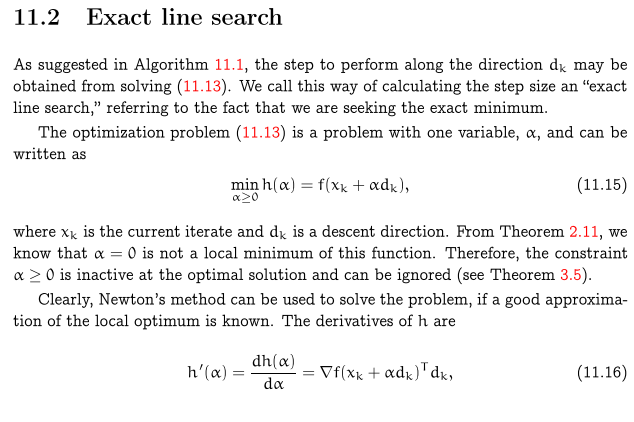

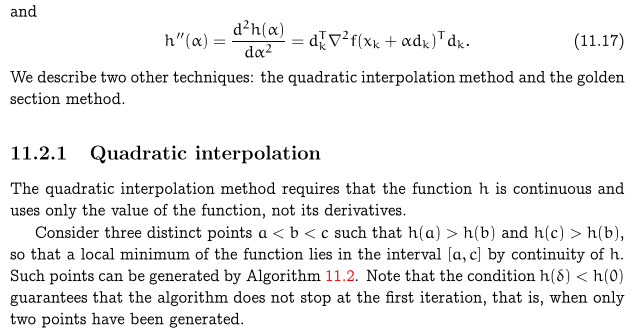

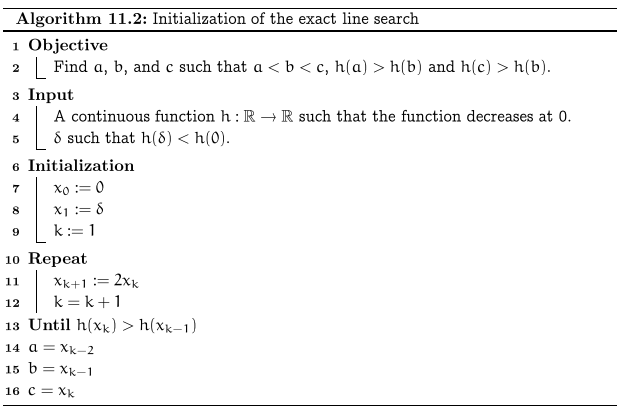

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

In [4]:
function quadratic_interpolation(h, δ, ε; max_iter=100)
    x0 = 0.0
    x1 = δ

    k = 1
    xs = [x0, x1]

    while true
        x_next = 2 * xs[end]
        push!(xs, x_next)

        if h(xs[end]) > h(xs[end-1])
            break
        end
    end

    a = xs[end-2]
    b = xs[end-1]
    c = xs[end]

    iter = 0

    # --- Iteração principal ---
    while iter < max_iter
        numerator = h(a)*(b^2 - c^2) + h(b)*(c^2 - a^2) + h(c)*(a^2 - b^2)
        denominator = h(a)*(b - c) + h(b)*(c - a) + h(c)*(a - b)

        x_star = 0.5 * numerator / denominator

        # evitar estagnação
        if h(x_star) == h(b)
            if (b - a) < (c - b)
                x_star += ε/2
            else
                x_star -= ε/2
            end
        end

        if x_star > b
            if h(x_star) > h(b)
                c = x_star
            else
                a = b
                b = x_star
            end
        else
            if h(x_star) > h(b)
                a = x_star
            else
                c = b
                b = x_star
            end
        end

        # critério de parada
        if max(h(a), h(c)) - h(b) ≤ ε || abs(c - a) ≤ ε
            break
        end

        iter += 1
    end

    return b, iter
end

quadratic_interpolation (generic function with 1 method)

Mínimo aproximado α*: 1.4256184490394652
Iterações: 11
h(α*): -3.2883713955908966


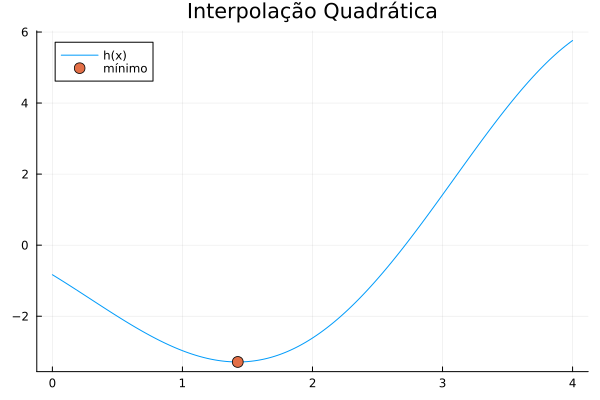

In [ ]:
h(x) = (2 + x) * cos(2 + x)

a_star, iter = quadratic_interpolation(h, 0.1, 1e-6)

println("Mínimo aproximado a*: ", a_star)
println("Iterações: ", iter)
println("h(a*): ", h(a_star))

xs = range(0, 4, length=200)
ys = h.(xs)

plot(xs, ys, label="h(x)", title="Interpolação Quadrática")

scatter!([a_star], [h(a_star)], label="mínimo", markersize=6)

### Algorithm 11.3: Exact line search: quadratic interpolation

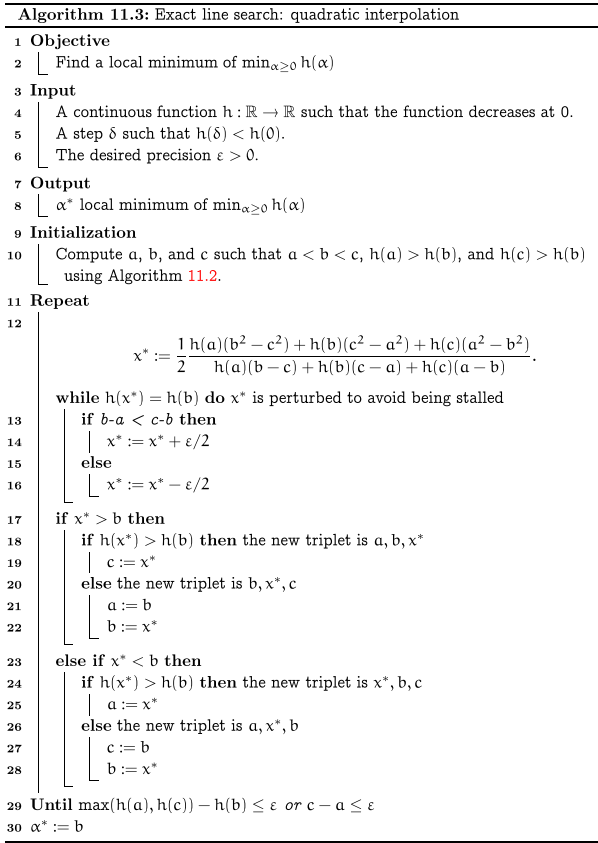

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

In [6]:
function interpolacao_quadratica(h, delta, epi; max_iter=100)
    # Algoritmo 11.2: inicializacao
    x0 = 0.0
    x1 = delta
    xs = [x0, x1]

    while true
        x_next = 2 * xs[end]
        push!(xs, x_next)

        if h(xs[end]) > h(xs[end-1])
            break
        end
    end

    a = xs[end-2]
    b = xs[end-1]
    c = xs[end]

    iter = 0

    while iter < max_iter
        num = h(a)*(b^2 - c^2) + h(b)*(c^2 - a^2) + h(c)*(a^2 - b^2)
        den = h(a)*(b - c) + h(b)*(c - a) + h(c)*(a - b)

        xstar = 0.5 * num / den

        if h(xstar) == h(b)
            if b - a < c - b
                xstar = xstar + epi/2
            else
                xstar = xstar - epi/2
            end
        end

        if xstar > b
            if h(xstar) > h(b)
                c = xstar
            else
                a = b
                b = xstar
            end
        elseif xstar < b
            if h(xstar) > h(b)
                a = xstar
            else
                c = b
                b = xstar
            end
        end

        iter += 1

        if max(h(a), h(c)) - h(b) <= epi || c - a <= epi
            break
        end
    end

    return b, iter
end

interpolacao_quadratica (generic function with 1 method)

alpha*: 1.4256184490394652
iteracoes: 12
h(alpha*): -3.2883713955908966


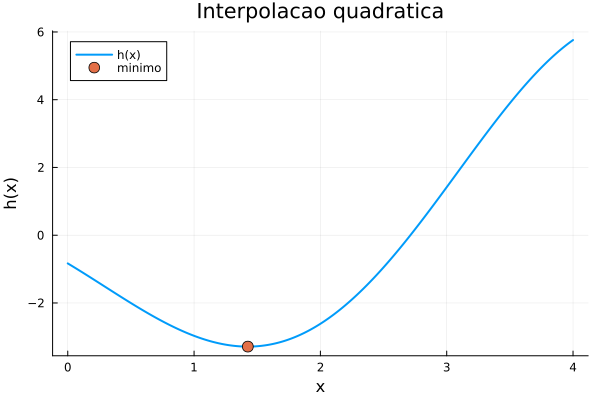

In [7]:
h(x) = (2 + x) * cos(2 + x)

delta = 0.1
epi = 1e-6

alpha_star, iter = interpolacao_quadratica(h, delta, epi)

println("alpha*: ", alpha_star)
println("iteracoes: ", iter)
println("h(alpha*): ", h(alpha_star))

x_vals = range(0, 4, length=300)
y_vals = h.(x_vals)

plot(
    x_vals,
    y_vals,
    linewidth=2,
    xlabel="x",
    ylabel="h(x)",
    title="Interpolacao quadratica",
    label="h(x)"
)

scatter!(
    [alpha_star],
    [h(alpha_star)],
    markersize=6,
    label="minimo"
)

### Algorithm 11.5: Line search

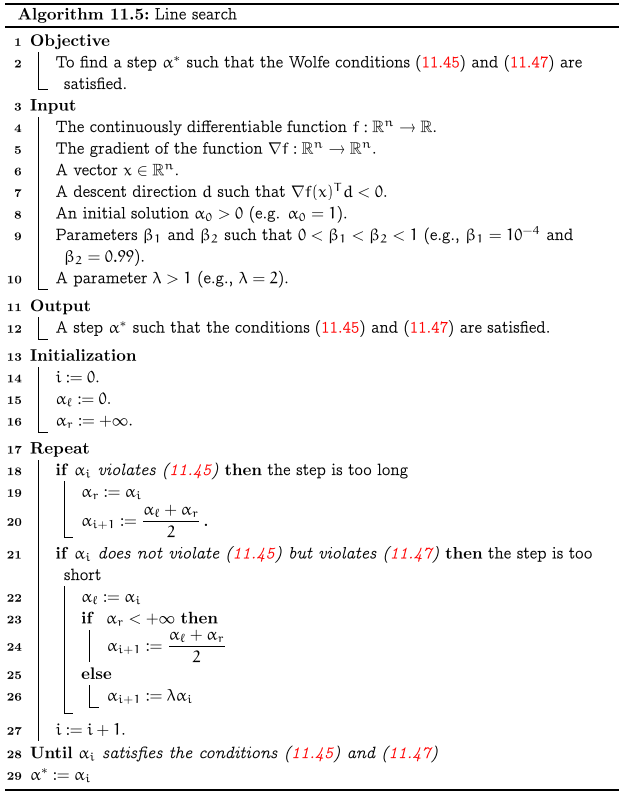

Example 11.2: $f(x) = \frac{1}{2} x_1^2 + \frac{9}{2} x_2^2$.

In [8]:
function line_search_wolfe(f, gradf, x, d, alpha0;
                           beta1=1e-4, beta2=0.99, lambda=2.0, max_iter=100)

    alpha_l = 0.0
    alpha_r = Inf
    alpha = alpha0

    fx = f(x)
    gx = gradf(x)
    gxd = dot(gx, d)

    i = 0

    while i < max_iter
        f_new = f(x + alpha*d)
        g_new = gradf(x + alpha*d)

        # Condicao 11.45: Armijo
        armijo = f_new <= fx + beta1*alpha*gxd

        # Condicao 11.47: curvatura de Wolfe
        curvatura = dot(g_new, d) >= beta2*gxd

        if armijo && curvatura
            return alpha, i
        end

        if !armijo
            # passo muito grande
            alpha_r = alpha
            alpha = (alpha_l + alpha_r)/2
        else
            # passo muito pequeno
            alpha_l = alpha

            if isfinite(alpha_r)
                alpha = (alpha_l + alpha_r)/2
            else
                alpha = lambda*alpha
            end
        end

        i += 1
    end

    return alpha, i
end

line_search_wolfe (generic function with 1 method)

In [9]:
f(x) = 0.5*x[1]^2 + 4.5*x[2]^2

gradf(x) = [
    x[1];
    9*x[2]
]

x = [1.0, 1.0]
d = -gradf(x)

alpha0 = 1.0

alpha_star, iter = line_search_wolfe(f, gradf, x, d, alpha0)

println("alpha*: ", alpha_star)
println("iteracoes: ", iter)
println("f(x): ", f(x))
println("f(x + alpha*d): ", f(x + alpha_star*d))
println("x novo: ", x + alpha_star*d)

alpha*: 0.125
iteracoes: 3
f(x): 5.0
f(x + alpha*d): 0.453125
x novo: [0.875, -0.125]


### Algorithm 11.6: Steepest descent

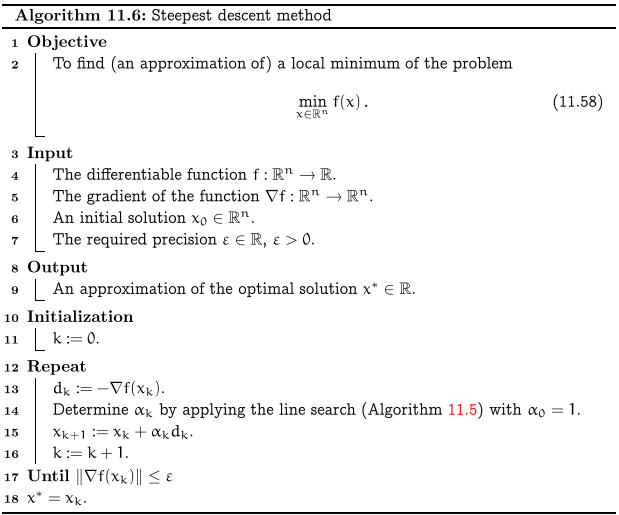

Test in the Rosenbrock function

In [10]:
function steepest_descent_plot(f, gradf, x0, epi; max_iter=10000)
    x = copy(x0)

    xs = [copy(x)]
    erros = [norm(gradf(x))]
    valores = [f(x)]
    alphas = Float64[]

    k = 0

    while norm(gradf(x)) > epi && k < max_iter
        d = -gradf(x)

        alpha, _ = line_search_wolfe(f, gradf, x, d, 1.0)

        x = x + alpha*d

        push!(xs, copy(x))
        push!(erros, norm(gradf(x)))
        push!(valores, f(x))
        push!(alphas, alpha)

        k += 1
    end

    return x, xs, erros, valores, alphas, k
end

steepest_descent_plot (generic function with 1 method)

Solução aproximada: [0.9999885309112244, 0.9999770472967094]
Iterações: 10000
Norma final: 1.7325138726746607e-5
Valor final f(x): 1.31561480926143e-10


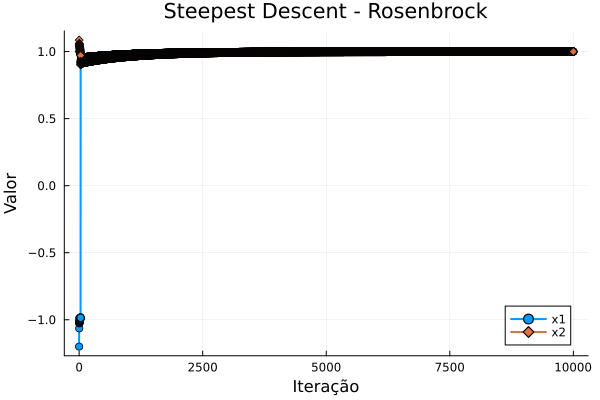

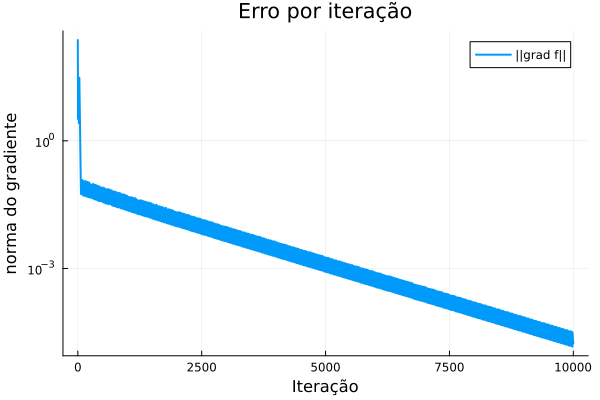

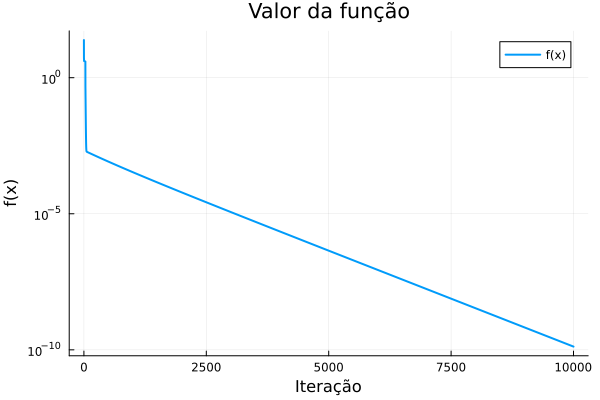

In [13]:
function rosenbrock(x)
    soma = 0.0
    for i in 1:length(x)-1
        soma += 100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2
    end
    return soma
end

function grad_rosenbrock(x)
    n = length(x)
    g = zeros(n)

    for i in 1:n-1
        g[i] += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end

    return g
end

x0 = [-1.2, 1.0]
epi = 1e-6

x_aprox, xs, erros, valores, alphas, iter = steepest_descent_plot(
    rosenbrock,
    grad_rosenbrock,
    x0,
    epi
)

println("Solução aproximada: ", x_aprox)
println("Iterações: ", iter)
println("Norma final: ", erros[end])
println("Valor final f(x): ", valores[end])

k_vals = 0:length(xs)-1
x1_vals = [x[1] for x in xs]
x2_vals = [x[2] for x in xs]

p1 = plot(
    k_vals,
    x1_vals,
    marker=:circle,
    linewidth=2,
    xlabel="Iteração",
    ylabel="Valor",
    title="Steepest Descent - Rosenbrock",
    label="x1"
)

plot!(p1, k_vals, x2_vals, marker=:diamond, linewidth=2, label="x2")
display(p1)

p2 = plot(
    k_vals,
    erros,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="norma do gradiente",
    title="Erro por iteração",
    label="||grad f||"
)

display(p2)

p3 = plot(
    k_vals,
    valores,
    linewidth=2,
    yscale=:log10,
    xlabel="Iteração",
    ylabel="f(x)",
    title="Valor da função",
    label="f(x)"
)

display(p3)